In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
datos = pd.read_csv("train.csv")
datos['date'] = pd.to_datetime(datos['date'])

datos.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
print("Dimension del Dataset:", datos.shape)

Dimension del Dataset: (913000, 4)


In [5]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


In [6]:
datos.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


# Observaciones hasta ahora

    No hay valores faltantes

    Datos continuos por dia

    931000 datos

    10 tiendas y 50 productos

Es un problema de series de tiempo multivariadas:
Cada tienda y prodcto es una seri de tiempo propia.

# Analisis Exploratorio

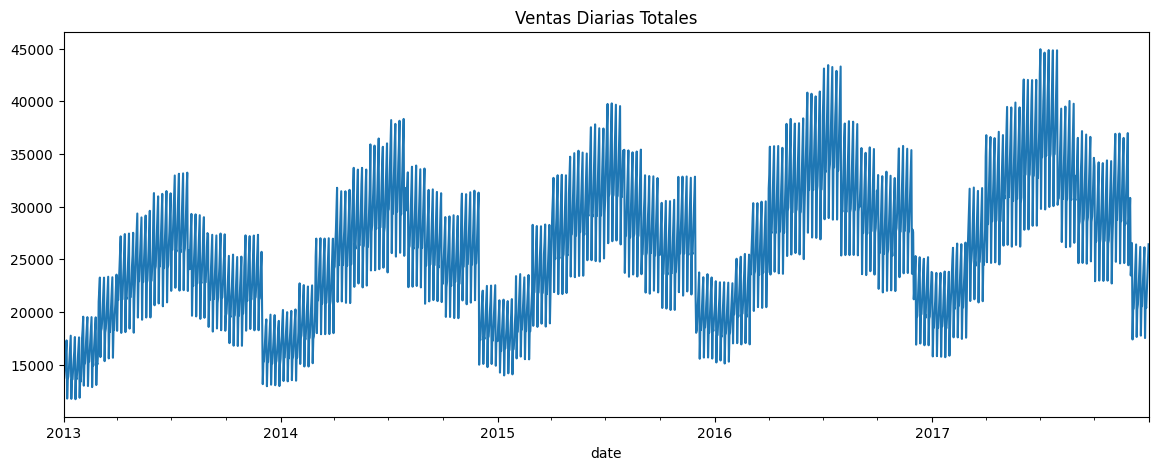

In [8]:
ventasDiarias = datos.groupby("date")["sales"].sum()

plt.figure(figsize=(14,5))
ventasDiarias.plot()
plt.title("Ventas Diarias Totales")
plt.show()

    Tiende a la alza
    Tiene una clara estacionalidad

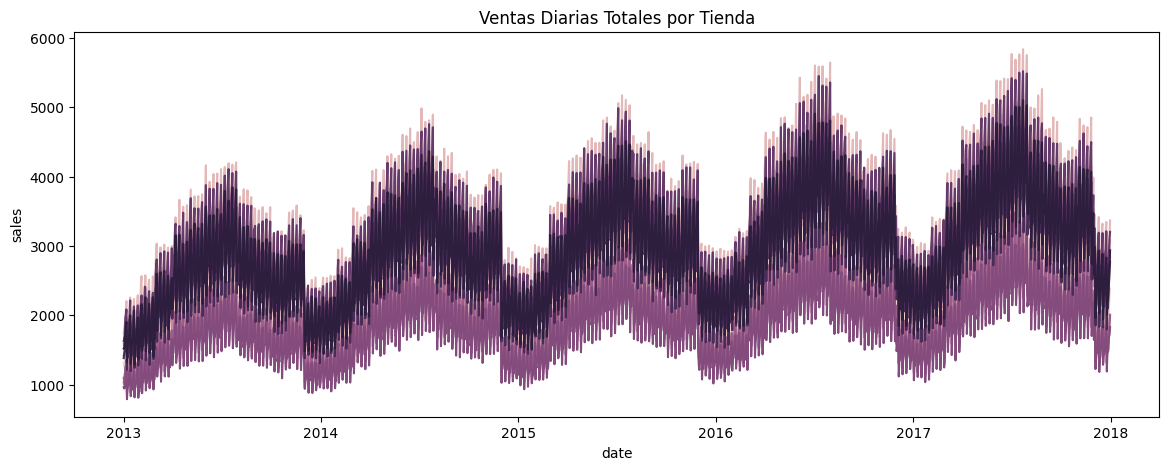

In [10]:
ventasTienda = datos.groupby(["date","store"])["sales"].sum().reset_index()

plt.figure(figsize=(14,5))
sns.lineplot(data=ventasTienda, x="date", y="sales", hue="store", legend=False)
plt.title("Ventas Diarias Totales por Tienda")
plt.show()

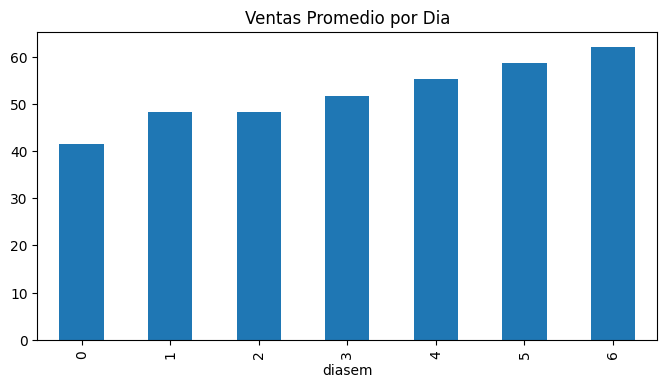

In [11]:
datos['diasem'] = datos['date'].dt.dayofweek

promDia = datos.groupby("diasem")["sales"].mean()

plt.figure(figsize=(8,4))
promDia.plot(kind="bar")
plt.title("Ventas Promedio por Dia")
plt.show()

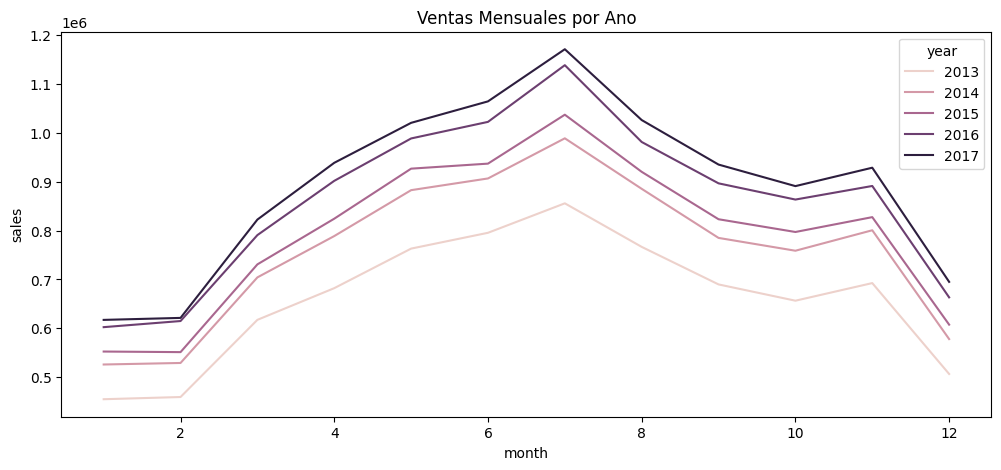

In [12]:
datos['month'] = datos['date'].dt.month
datos['year'] = datos['date'].dt.year

ventasMes = datos.groupby(['year','month'])['sales'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=ventasMes, x='month', y='sales', hue='year', legend=True)
plt.title("Ventas Mensuales por Ano")
plt.show()

    Un ciclo repetitivo marcado

    Mayor demanda en meses específicos

    Patrón constante a lo largo de los años


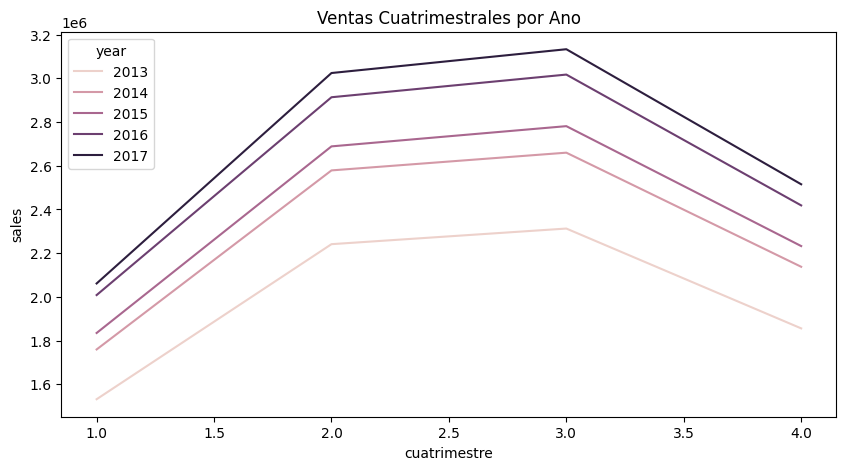

In [16]:
datos['cuatrimestre'] = datos['date'].dt.quarter

ventasCuatri = datos.groupby(['year','cuatrimestre'])['sales'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=ventasCuatri, x='cuatrimestre', y='sales', hue='year')
plt.title("Ventas Cuatrimestrales por Ano")
plt.show()